In [1]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='',
    database='ventas_tech'
)

print("Conexión exitosa")

Conexión exitosa


In [2]:
query = """
SELECT 
    p.id_pedido,
    c.nombre AS cliente,
    c.ciudad,
    c.segmento,
    pr.nombre AS producto,
    cat.nombre AS categoria,
    p.cantidad,
    pr.precio,
    p.descuento,
    ROUND(p.cantidad * pr.precio * (1 - p.descuento), 2) AS total,
    p.fecha
FROM pedidos p
JOIN clientes c ON p.id_cliente = c.id_cliente
JOIN productos pr ON p.id_producto = pr.id_producto
JOIN categorias cat ON pr.id_categoria = cat.id_categoria
ORDER BY p.fecha
"""

df = pd.read_sql(query, conn)
print("Filas cargadas:", len(df))
df.head()

Filas cargadas: 30


C:\Users\julia\AppData\Local\Temp\ipykernel_18656\4288394798.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id_pedido,cliente,ciudad,segmento,producto,categoria,cantidad,precio,descuento,total,fecha
0,1,Carlos Garcia,Madrid,Enterprise,MacBook Pro 14,Laptops,2,1999.99,0.10,3599.98,2023-01-20
1,2,Carlos Garcia,Madrid,Enterprise,Monitor LG 27UK850,Monitores,1,599.99,0.00,599.99,2023-01-25
2,3,Laura Martinez,Barcelona,SMB,iPhone 15 Pro,Smartphones,1,1199.99,0.05,1139.99,2023-02-28
3,4,Laura Martinez,Barcelona,SMB,Logitech MX Master 3,Accesorios,2,99.99,0.00,199.98,2023-03-05
4,5,Pedro Sanchez,Valencia,Consumer,Xiaomi 13 Pro,Smartphones,1,799.99,0.00,799.99,2023-03-15


In [3]:
df['fecha'] = pd.to_datetime(df['fecha'])
df['mes'] = df['fecha'].dt.month

print("=== RESUMEN DEL NEGOCIO ===")
print(f"Total pedidos: {len(df)}")
print(f"Total ingresos: ${df['total'].sum():,.2f}")
print(f"Ticket medio: ${df['total'].mean():,.2f}")
print(f"Cliente top: {df.groupby('cliente')['total'].sum().idxmax()}")
print(f"Categoría top: {df.groupby('categoria')['total'].sum().idxmax()}")

=== RESUMEN DEL NEGOCIO ===
Total pedidos: 30
Total ingresos: $35,584.51
Ticket medio: $1,186.15
Cliente top: Ana Lopez
Categoría top: Laptops


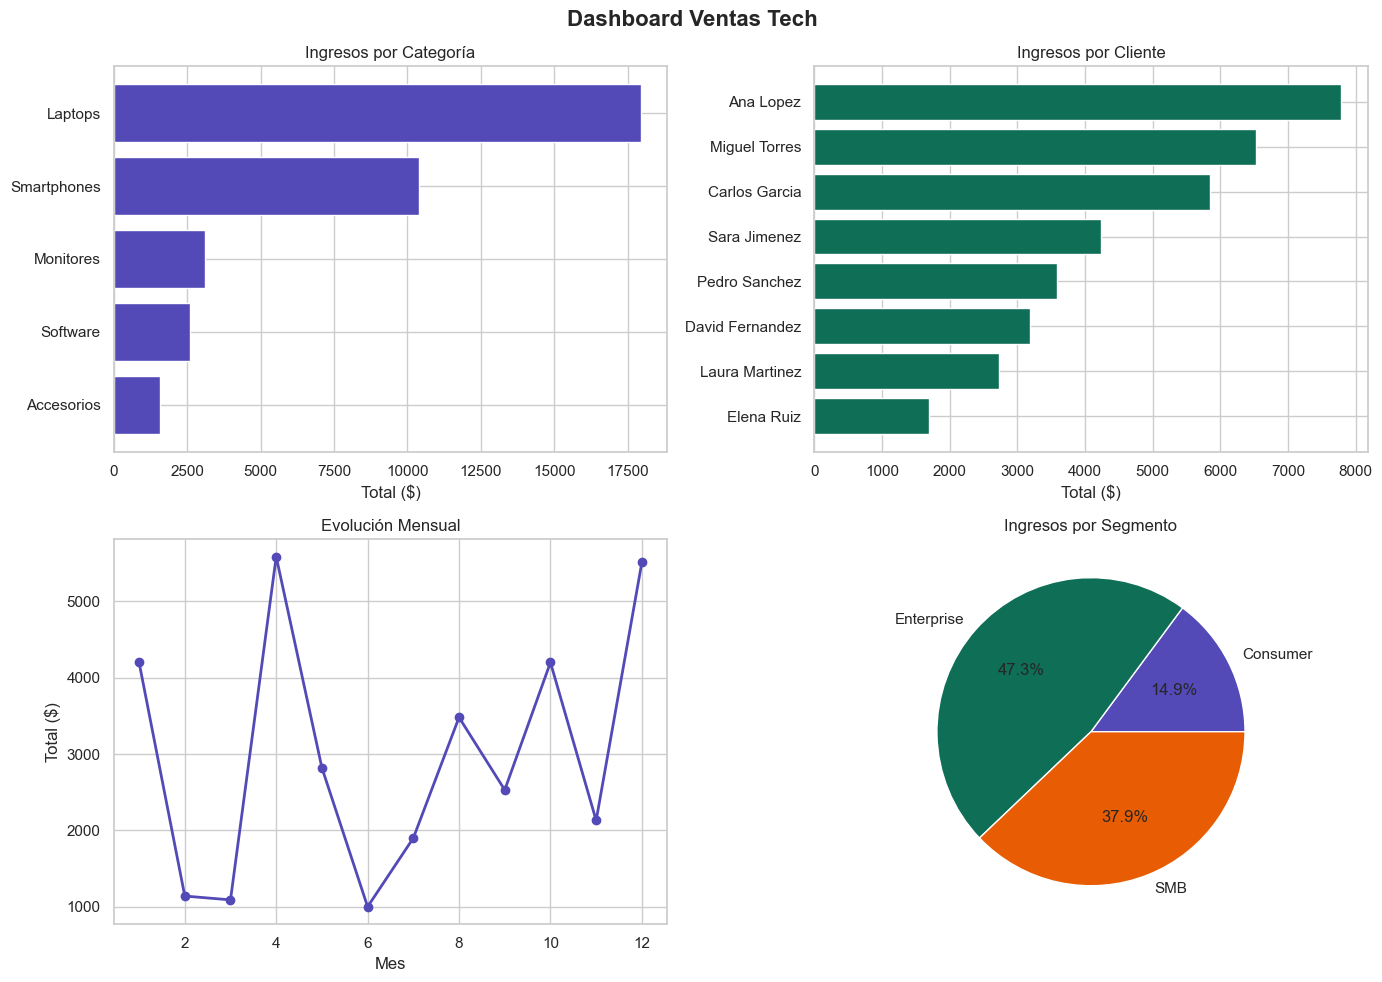

In [4]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dashboard Ventas Tech', fontsize=16, fontweight='bold')

# Gráfico 1 — Ingresos por categoría
cat_ventas = df.groupby('categoria')['total'].sum().sort_values(ascending=True)
axes[0,0].barh(cat_ventas.index, cat_ventas.values, color='#534AB7')
axes[0,0].set_title('Ingresos por Categoría')
axes[0,0].set_xlabel('Total ($)')

# Gráfico 2 — Ingresos por cliente
cli_ventas = df.groupby('cliente')['total'].sum().sort_values(ascending=True)
axes[0,1].barh(cli_ventas.index, cli_ventas.values, color='#0F6E56')
axes[0,1].set_title('Ingresos por Cliente')
axes[0,1].set_xlabel('Total ($)')

# Gráfico 3 — Evolución mensual
mes_ventas = df.groupby('mes')['total'].sum()
axes[1,0].plot(mes_ventas.index, mes_ventas.values, 
               color='#534AB7', linewidth=2, marker='o')
axes[1,0].set_title('Evolución Mensual')
axes[1,0].set_xlabel('Mes')
axes[1,0].set_ylabel('Total ($)')

# Gráfico 4 — Ingresos por segmento
seg_ventas = df.groupby('segmento')['total'].sum()
axes[1,1].pie(seg_ventas.values, labels=seg_ventas.index, 
              autopct='%1.1f%%', colors=['#534AB7','#0F6E56','#E85D04'])
axes[1,1].set_title('Ingresos por Segmento')

plt.tight_layout()
plt.show()